# Milestone 2 – Visual Exploration and Delay Trends

This milestone focuses on exploratory data analysis, delay trends, airline performance comparison, and seasonal insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("airline_operations.csv")

df.fillna(0, inplace=True)

df['delay_rate'] = df['arr_del15'] / df['arr_flights']
df['cancel_rate'] = df['arr_cancelled'] / df['arr_flights']
df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))

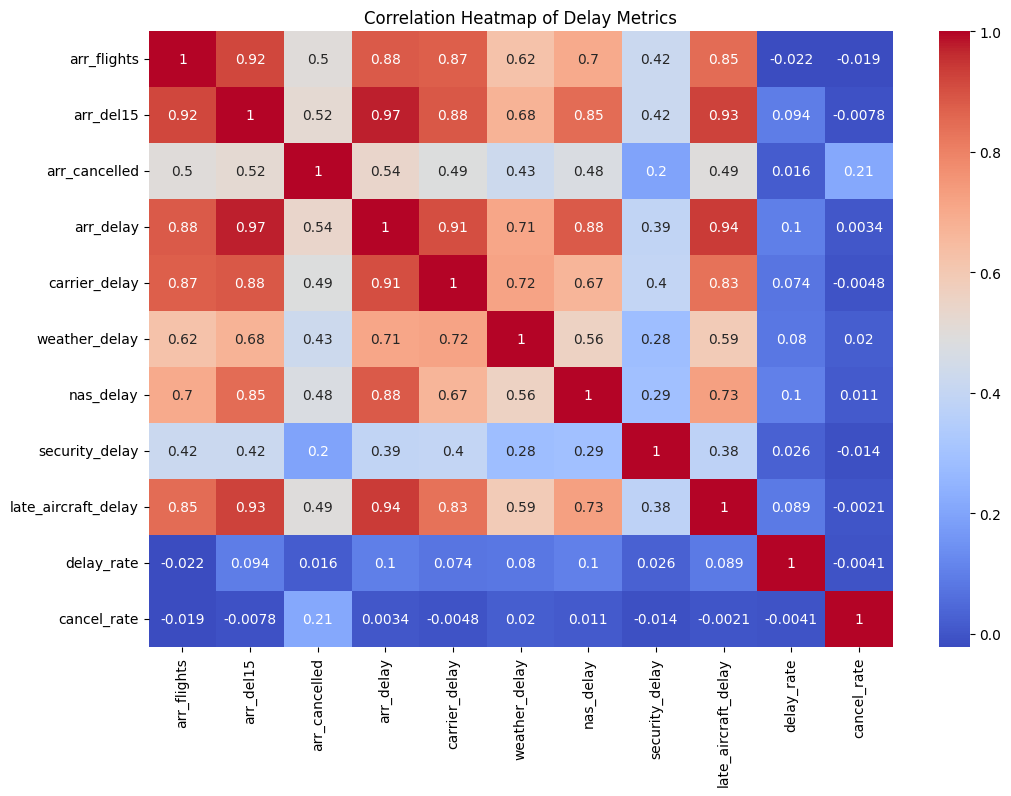

In [6]:
numeric_cols = [
    'arr_flights','arr_del15','arr_cancelled','arr_delay',
    'carrier_delay','weather_delay','nas_delay',
    'security_delay','late_aircraft_delay',
    'delay_rate','cancel_rate'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Delay Metrics")
plt.show()

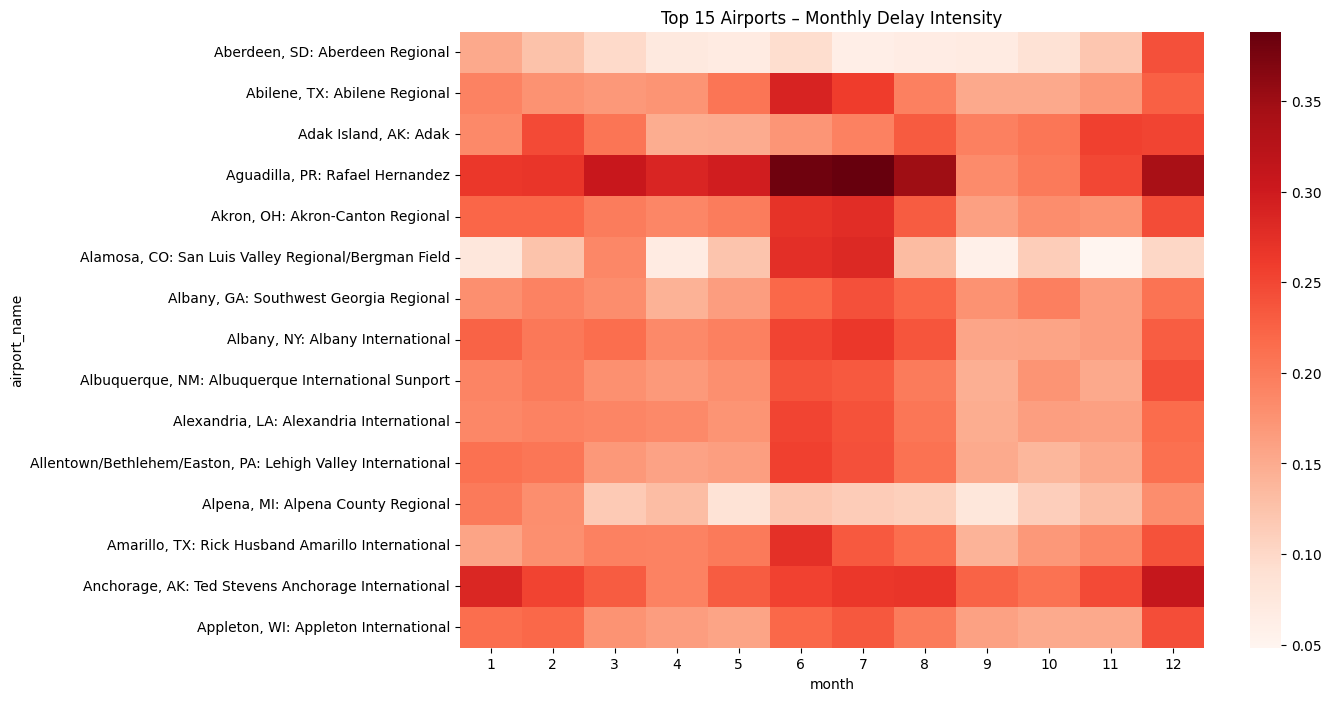

In [7]:
pivot = df.pivot_table(values='delay_rate',
                       index='airport_name',
                       columns='month',
                       aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot.head(15), cmap='Reds')
plt.title("Top 15 Airports – Monthly Delay Intensity")
plt.show()

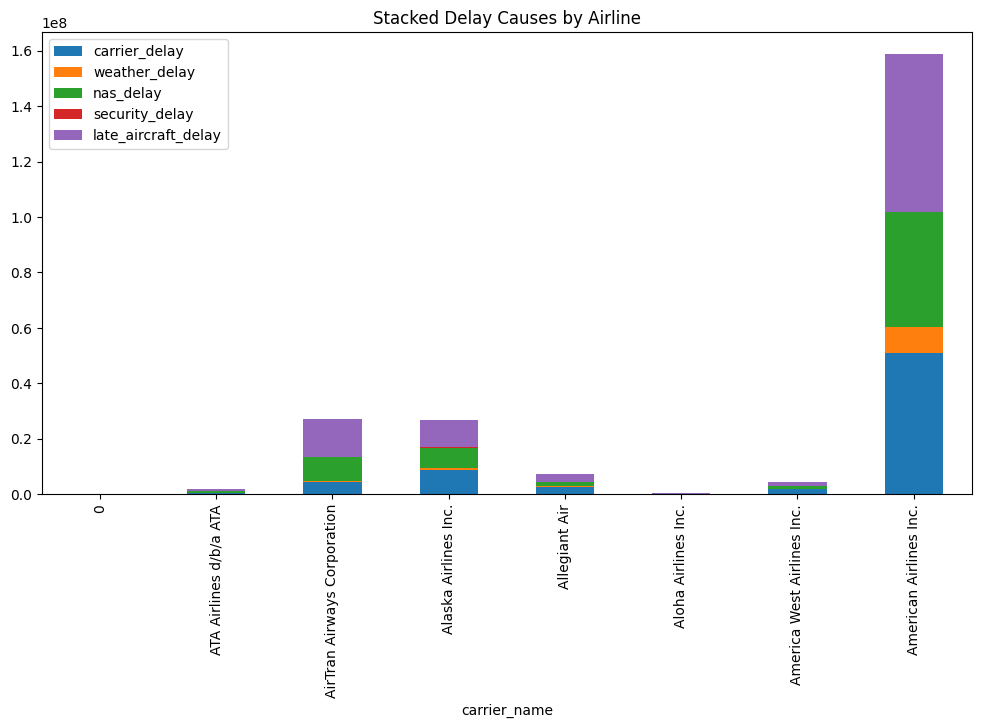

In [ ]:
delay_columns = [
    'carrier_delay','weather_delay',
    'nas_delay','security_delay','late_aircraft_delay'
]

carrier_delay = df.groupby('carrier_name')[delay_columns].sum().head(8)

carrier_delay.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Stacked Delay Causes by Airline")
plt.show()

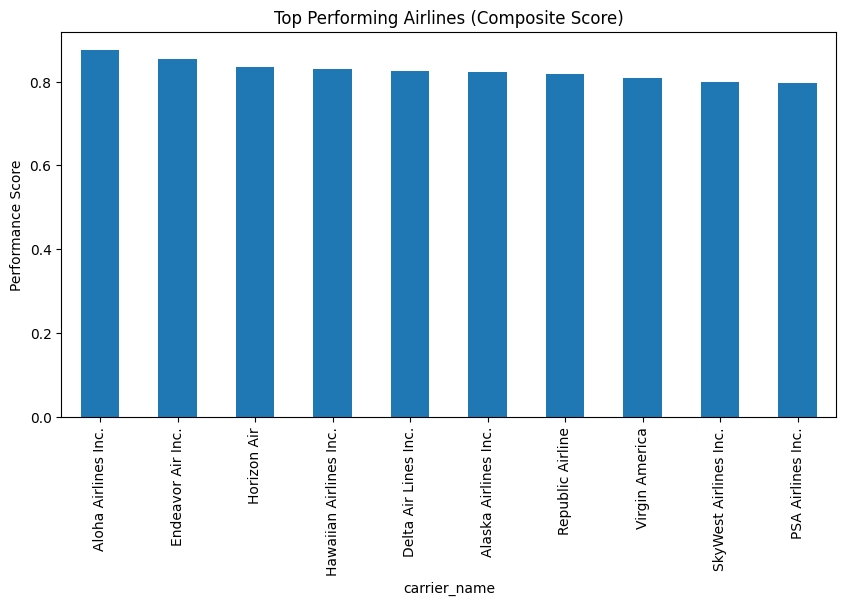

In [9]:
df['performance_score'] = 1 - (df['delay_rate'] + df['cancel_rate'])

performance = df.groupby('carrier_name')['performance_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
performance.plot(kind='bar')
plt.title("Top Performing Airlines (Composite Score)")
plt.ylabel("Performance Score")
plt.show()

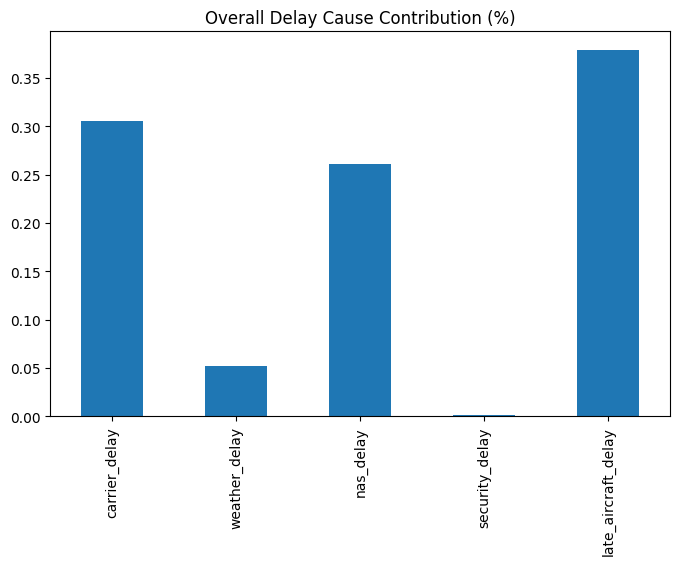

In [10]:
total_delays = df[delay_columns].sum()
delay_pct = total_delays / total_delays.sum()

plt.figure(figsize=(8,5))
delay_pct.plot(kind='bar')
plt.title("Overall Delay Cause Contribution (%)")
plt.show()

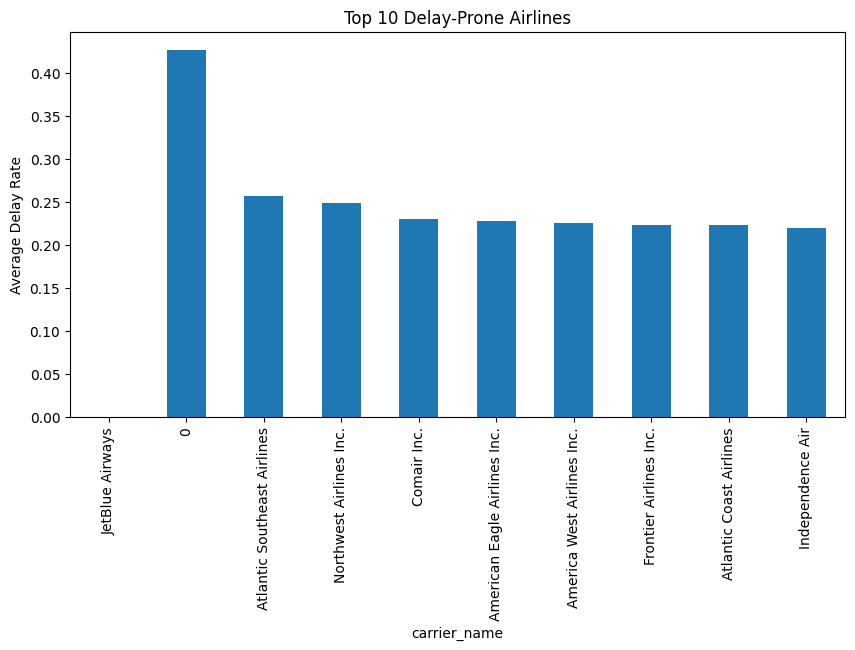

In [12]:
delay_ranking = df.groupby('carrier_name')['delay_rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
delay_ranking.plot(kind='bar')
plt.title("Top 10 Delay-Prone Airlines")
plt.ylabel("Average Delay Rate")
plt.show()

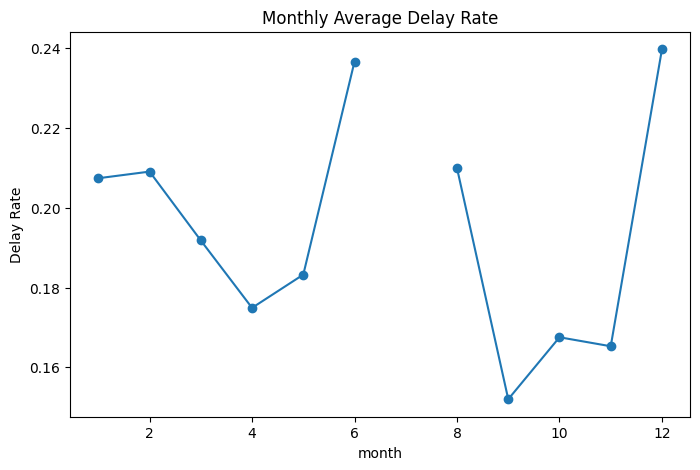

In [13]:
monthly_delay = df.groupby('month')['delay_rate'].mean()

plt.figure(figsize=(8,5))
monthly_delay.plot(marker='o')
plt.title("Monthly Average Delay Rate")
plt.ylabel("Delay Rate")
plt.show()

## Observations – Milestone 2

- Carrier-related delays contribute the highest portion of total delays.
- Certain airlines show consistently higher delay rates.
- Delay rates peak during specific months, indicating seasonal effects.
- Some airports experience higher delay intensity.